In [112]:
import pandas as pd
import numpy as np
import os
import pickle
from IPython.display import Image, display
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, LSTM, Bidirectional, Concatenate, Input, AdditiveAttention, GlobalAveragePooling1D, Lambda
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error, mean_absolute_error
from tensorflow.keras.saving import register_keras_serializable
import matplotlib.pyplot as plt
import seaborn as sns

In [113]:
df = pd.read_csv('https://raw.githubusercontent.com/mahadidn/wind-speed-forecasting/refs/heads/main/datasets/1994-2025-univariat.csv')
df.head(5)

,TANGGAL,FF_AVG
0,1994-03-01,11.0
1,1994-03-02,10.0
2,1994-03-03,9.0
3,1994-03-04,5.0
4,1994-03-05,3.0


In [114]:
# Pembagian data 70% training, 20% validasi, dan 10% testing
n = len(df)
n_train = int(n * 0.70)
n_val   = int(n * 0.20)
n_test  = n - n_train - n_val

train_df = df.iloc[:n_train].copy()
val_df   = df.iloc[n_train : n_train + n_val].copy()
test_df  = df.iloc[n_train + n_val :].copy()

print(f"Total: {n}, Train: {n_train}, Val: {n_val}, Test: {n_test}")

# cek tanggal berapa saja yang dipakai
print("Training range:", train_df['TANGGAL'].min(), "–", train_df['TANGGAL'].max())
print("Validation range:", val_df['TANGGAL'].min(), "–", val_df['TANGGAL'].max())
print("Testing range:", test_df['TANGGAL'].min(), "–", test_df['TANGGAL'].max())

Total: 11354, Train: 7947, Val: 2270, Test: 1137
Training range: 1994-03-01 – 2015-12-02
Validation range: 2015-12-03 – 2022-02-18
Testing range: 2022-02-19 – 2025-03-31


In [115]:
# fitur dan target
feature_cols = [col for col in df.columns if col != 'TANGGAL']
target_col = 'FF_AVG'

X_train = train_df[feature_cols].values
X_val = val_df[feature_cols].values
X_test = test_df[feature_cols].values

y_train = train_df[target_col].values
y_val = val_df[target_col].values
y_test = test_df[target_col].values

In [116]:
# data scaler menggunakan min max
X_scaler = MinMaxScaler()
X_train_scaled = X_scaler.fit_transform(X_train)
X_val_scaled = X_scaler.transform(X_val)
X_test_scaled = X_scaler.transform(X_test)

y_scaler = MinMaxScaler()
y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
y_val_scaled = y_scaler.transform(y_val.reshape(-1, 1)).flatten()
y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1)).flatten()

# Save scalers
os.makedirs('models', exist_ok=True)
with open("models/X_scaler.pkl", "wb") as f:
    pickle.dump(X_scaler, f)

with open("models/y_scaler.pkl", "wb") as f:
    pickle.dump(y_scaler, f)

In [117]:
# membuat sliding window untuk multistep forecasting
def create_multistep_sequences(X, y, time_steps, forecast_horizon):
    """Create sequences for multi-step time series prediction"""
    if len(X) <= time_steps + forecast_horizon:
        raise ValueError(f"Data length ({len(X)}) must be greater than time_steps + forecast_horizon ({time_steps + forecast_horizon})")

    Xs, ys = [], []
    for i in range(len(X) - time_steps - forecast_horizon + 1):
        # Input sequence
        Xs.append(X[i : (i + time_steps)])
        # Multi-step output sequence
        ys.append(y[i + time_steps : i + time_steps + forecast_horizon])
    return np.array(Xs), np.array(ys)

# Multi-step forecasting parameters
time_steps = 60
forecast_horizon = 30

# Buat multi-step sequences
X_train_seq, y_train_seq = create_multistep_sequences(X_train_scaled, y_train_scaled, time_steps, forecast_horizon)
X_val_seq, y_val_seq = create_multistep_sequences(X_val_scaled, y_val_scaled, time_steps, forecast_horizon)
X_test_seq, y_test_seq = create_multistep_sequences(X_test_scaled, y_test_scaled, time_steps, forecast_horizon)

print(f"Multi-step sequences shapes:")
print(f"X_train_seq: {X_train_seq.shape}, y_train_seq: {y_train_seq.shape}")
print(f"X_val_seq: {X_val_seq.shape}, y_val_seq: {y_val_seq.shape}")
print(f"X_test_seq: {X_test_seq.shape}, y_test_seq: {y_test_seq.shape}")

Multi-step sequences shapes:
X_train_seq: (7858, 60, 1), y_train_seq: (7858, 30)
X_val_seq: (2181, 60, 1), y_val_seq: (2181, 30)
X_test_seq: (1048, 60, 1), y_test_seq: (1048, 30)


In [118]:
# Buat model BiLSTM-Attention
def create_model_bilstm_attention(units=64, forecast_horizon=30, n_layers=2):

    input_shape = (X_train_seq.shape[1], X_train_seq.shape[2])
    inputs = Input(shape=input_shape, name='input_sequences')

    x = inputs

    # Lapisan BiLSTM
    for i in range(n_layers):
        x = Bidirectional(
            LSTM(units,
                 activation='relu',
                 return_sequences=True),
            name=f'bilstm_{i+1}'
        )(x)


    # x shape: (batch_size, time_steps, 2*units) - BiLSTM output
    bilstm_output = x

    context_vector = AdditiveAttention(name='attention_layer')([bilstm_output, bilstm_output])

    # global pooling untuk mereduksi output attention menjadi single vektor
    context_vector = GlobalAveragePooling1D(name='global_pooling')(context_vector)
    dense_1 = Dense(64, activation='relu', name='dense_1')(context_vector)

    # output layer untuk multi-step forecasting
    output = Dense(forecast_horizon, activation='linear', name='output')(dense_1)

    # buat model
    model = Model(inputs=inputs, outputs=output, name='BiLSTM_Attention_MultiStep')

    # Compile dengan optimizer
    model.compile(
        optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
        loss='mae',
        metrics=['mae']
    )

    return model

# Membuat model BiLSTM-Attention
print("Membuat Model BiLSTM with Attention model...")
model = create_model_bilstm_attention(
    units=64,
    forecast_horizon=forecast_horizon,
    n_layers=2
)
model.summary()


Membuat Model BiLSTM with Attention model...


Model: "BiLSTM_Attention_MultiStep"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_sequences     │ (None, 60, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_1            │ (None, 60, 128)   │     33,792 │ input_sequences[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_2            │ (None, 60, 128)   │     98,816 │ bilstm_1[0][0]    │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_layer     │ (None, 60, 128)   │        128 │ bilstm_2[0][0],   │
│ (AdditiveAttention) │                   │            │ bilstm_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_pooling      │ (None, 128)       │          0 │ attention_layer[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ global_pooling[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 30)        │      1,950 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 142,942 (558.37 KB)

 Trainable params: 142,942 (558.37 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Callbacks
# jika tidak ada perubahan pada proses training turunkan nilai learning rate agar konvergen
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=0.000001,
    verbose=1
)

# Training
history_multistep = model.fit(
    X_train_seq, y_train_seq,
    epochs=100,
    batch_size=32,
    validation_data=(X_val_seq, y_val_seq),
    callbacks=[reduce_lr],
    shuffle=False,
    verbose=1
)

# Save model and history
try:
    model.save('models/multistep_model.keras')
    print("Multi-step model berhasil disimpan!")

    with open('models/multistep_history.pkl', 'wb') as f:
        pickle.dump(history_multistep.history, f)
    print("Training history berhasil disimpan!")

except Exception as e:
    print(f"Error saving model: {e}")

Epoch 1/100
246/246 ━━━━━━━━━━━━━━━━━━━━ 29s 61ms/step - loss: 0.1730 - mae: 0.1730 - val_loss: 0.1021 - val_mae: 0.1021 - learning_rate: 0.0010
Epoch 2/100
246/246 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 0.1109 - mae: 0.1109 - val_loss: 0.1107 - val_mae: 0.1107 - learning_rate: 0.0010
Epoch 3/100
246/246 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - loss: 0.1089 - mae: 0.1089 - val_loss: 0.1092 - val_mae: 0.1092 - learning_rate: 0.0010
Epoch 4/100
246/246 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - loss: 0.1089 - mae: 0.1089 - val_loss: 0.1220 - val_mae: 0.1220 - learning_rate: 0.0010
Epoch 5/100
246/246 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.1075 - mae: 0.1075 - val_loss: 0.1209 - val_mae: 0.1209 - learning_rate: 0.0010
Epoch 6/100
244/246 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.1077 - mae: 0.1077
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
246/246 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - loss: 0.1075 - mae: 0.1075 - val_loss: 0.1202 - val_mae: 0.1202 - learnin

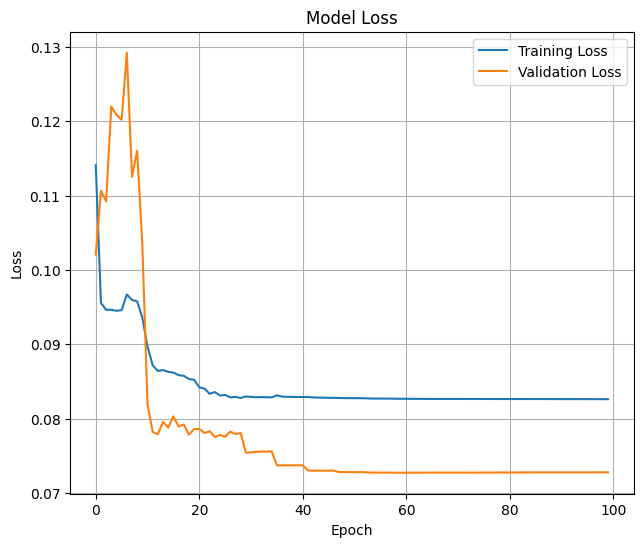

In [ ]:
# Plot training history
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
plt.plot(history_multistep.history['loss'], label='Training Loss')
plt.plot(history_multistep.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

In [119]:
# load model bilstm-attention
model = tf.keras.models.load_model('models/multistep_model.keras')

In [120]:
# Evaluasi Multi-step
def calculate_multistep_metrics(y_true, y_pred):
    """Hitung metrik evaluasi untuk multi-step forecasting"""

    metrics = {}
    n_steps = y_true.shape[1]

    # Keseluruhan metrik
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred.flatten()

    metrics['keseluruhan'] = {
        'mae': mean_absolute_error(y_true_flat, y_pred_flat),
        'mape': mean_absolute_percentage_error(y_true_flat, y_pred_flat) * 100,
        'rmse': np.sqrt(mean_squared_error(y_true_flat, y_pred_flat))
    }

    # metrik tiap langkah
    metrics['langkah'] = {}
    for step in range(n_steps):
        step_true = y_true[:, step]
        step_pred = y_pred[:, step]

        metrics['langkah'][f'step_{step+1}'] = {
            'mae': mean_absolute_error(step_true, step_pred),
            'mape': mean_absolute_percentage_error(step_true, step_pred) * 100,
            'rmse': np.sqrt(mean_squared_error(step_true, step_pred))
        }

    return metrics


In [125]:
# Evaluasi
print("Making multi-step predictions...")
try:
    y_pred_multistep_scaled = model.predict(X_test_seq, verbose=0)
    print(f"Prediction shape: {y_pred_multistep_scaled.shape}")

    # Inverse ke bentuk aslinya
    n_samples, n_steps = y_pred_multistep_scaled.shape
    y_pred_multistep_reshaped = y_pred_multistep_scaled.reshape(-1, 1)
    y_test_seq_reshaped = y_test_seq.reshape(-1, 1)

    y_pred_multistep_original = y_scaler.inverse_transform(y_pred_multistep_reshaped).reshape(n_samples, n_steps)
    y_test_seq_original = y_scaler.inverse_transform(y_test_seq_reshaped).reshape(n_samples, n_steps)

    # Hitung multi-step metric
    multistep_metrics = calculate_multistep_metrics(y_test_seq_original, y_pred_multistep_original)

    # Display results
    print("\n" + "=" * 60)
    print("=== Hasil Evaluasi MULTI-STEP FORECASTING ===")
    print("=" * 60)

    print("\n--- Keseluruhan Performa ---")
    keseluruhan = multistep_metrics['keseluruhan']
    print(f'Mean Absolute Error (MAE):     {keseluruhan["mae"]:.4f}')
    print(f'Mean Absolute Percentage Error (MAPE): {keseluruhan["mape"]:.2f}%')
    print(f'Root Mean Square Error (RMSE): {keseluruhan["rmse"]:.4f}')

    print(f"\n--- Performa tiap langkah, ({forecast_horizon} langkah berikutnya) ---")
    print(f"{'Step':<6} {'MAE':<8} {'MAPE(%)':<10} {'RMSE':<8}")
    print("-" * 50)

    for step_name, step_metrics in multistep_metrics['langkah'].items():
        step_num = step_name.split('_')[1]
        print(f"{step_num:<6} {step_metrics['mae']:<8.4f} {step_metrics['mape']:<10.2f} "
              f"{step_metrics['rmse']:<8.4f}")

    print("=" * 60)

    # Simpan detail prediksi
    predictions_detailed = []
    for i in range(len(y_test_seq_original)):
        for step in range(forecast_horizon):
            predictions_detailed.append({
                'sampel_idx': i,
                'forecast_step': step + 1,
                'aktual': y_test_seq_original[i, step],
                'prediksi': y_pred_multistep_original[i, step],
                'selisih': y_test_seq_original[i, step] - y_pred_multistep_original[i, step]
            })

    predictions_df = pd.DataFrame(predictions_detailed)
    predictions_df.to_csv('models/multistep_predictions.csv', index=False)
    print("Detail hasil prediksi tersimpan ke models/multistep_predictions.csv")

    # Save metrics
    with open('models/multistep_metrics.pkl', 'wb') as f:
        pickle.dump(multistep_metrics, f)
    print("Metrik berhasil tersimpan ke models/multistep_metrics.pkl")

except Exception as e:
    print(f"Error: {e}")
    raise

Making multi-step predictions...
Prediction shape: (1048, 30)

=== Hasil Evaluasi MULTI-STEP FORECASTING ===

--- Keseluruhan Performa ---
Mean Absolute Error (MAE):     0.7105
Mean Absolute Percentage Error (MAPE): 29.09%
Root Mean Square Error (RMSE): 1.0098

--- Performa tiap langkah, (30 langkah berikutnya) ---
Step   MAE      MAPE(%)    RMSE    
--------------------------------------------------
1      0.5641   24.62      0.8150  
2      0.6017   25.76      0.8615  
3      0.6197   26.33      0.8919  
4      0.6321   26.79      0.9149  
5      0.6523   27.32      0.9459  
6      0.6636   27.69      0.9597  
7      0.6669   27.77      0.9603  
8      0.6676   27.48      0.9629  
9      0.6706   27.56      0.9650  
10     0.6726   27.62      0.9691  
11     0.6831   28.04      0.9846  
12     0.7005   28.70      1.0024  
13     0.7108   28.84      1.0142  
14     0.7188   29.11      1.0179  
15     0.7271   29.61      1.0264  
16     0.7337   30.08      1.0314  
17     0.7280   29.6

In [126]:
# Plot sample forecasting
def plot_sample_predictions(y_true, y_pred, n_samples=1, save_path='models/sample_predictions.png'):
    """Plot sample multi-step forecasting"""
    fig, axes = plt.subplots(n_samples, 1, figsize=(12, 4*n_samples))
    if n_samples == 1:
        axes = [axes]

    for i in range(min(n_samples, len(y_true))):
        axes[i].plot(range(1, forecast_horizon+1), y_true[i], 'bo-', label='Aktual', linewidth=2)
        axes[i].plot(range(1, forecast_horizon+1), y_pred[i], 'ro-', label='Prediksi', linewidth=2)
        axes[i].set_title(f'Prediksi 30 langkah kedepan')
        axes[i].set_xlabel('Time steps (Harian)')
        axes[i].set_ylabel('Kecepatan Angin (m/s)')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)


    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"plot sampel prediksi tersimpan ke {save_path}")


plot sampel prediksi tersimpan ke models/sample_predictions.png


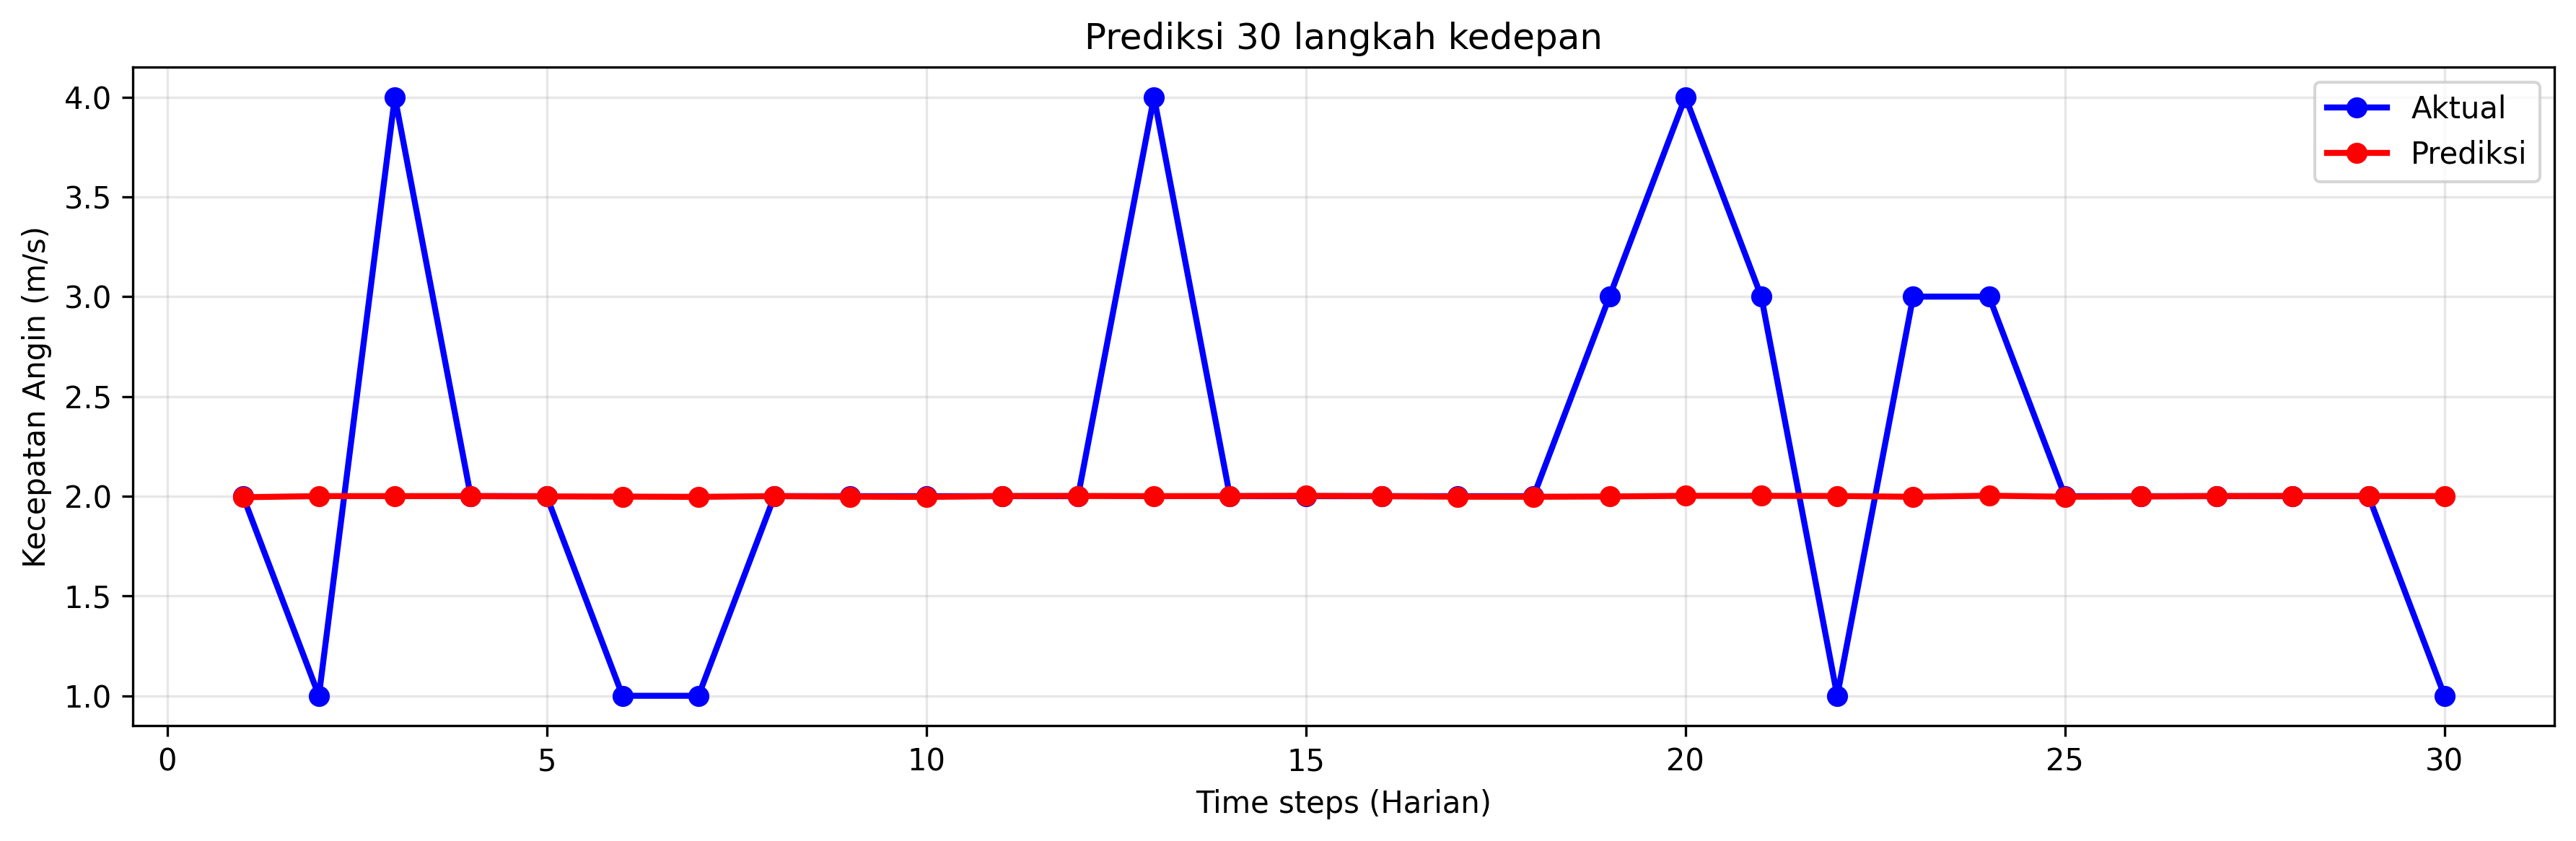

In [129]:
# Buat plot
plot_sample_predictions(y_test_seq_original, y_pred_multistep_original)
display(Image(filename='models/sample_predictions.png'))

In [157]:
# prediksi 30 langkah kedepan dari data baru
def predict_next_n_steps(latest_sequence, model, X_scaler, y_scaler, time_steps=60, forecast_horizon=30):
    """
    Prediksi 30 langkah ke depan dari data terbaru menggunakan model multi-step.

    Parameters:
    - latest_sequence: ndarray, shape (time_steps, fitur)
        Urutan data terkini yang akan digunakan sebagai input prediksi.
    - model: trained keras model
    - X_scaler: fitted MinMaxScaler untuk fitur
    - y_scaler: fitted MinMaxScaler untuk target
    - time_steps: panjang jendela waktu
    - forecast_horizon: jumlah langkah ke depan yang ingin diprediksi

    Returns:
    - pred_original: ndarray, shape (forecast_horizon,)
        Prediksi dalam skala asli (setelah inverse transform)
    """
    if latest_sequence.shape[0] != time_steps:
        raise ValueError(f"Data harus berjumlah ({time_steps}), data yang diinputkan berjumlah {latest_sequence.shape[0]}")

    # Normalisasi data 60 terakhir
    latest_scaled = X_scaler.transform(latest_sequence)
    # print(latest_scaled)

    # Ubah ke bentuk (1, time_steps, n_features) untuk prediksi
    input_seq = np.expand_dims(latest_scaled, axis=0)
    # print("input seq: ", input_seq.shape[0])

    # Prediksi
    pred_scaled = model.predict(input_seq, verbose=0)[0]  # shape: (forecast_horizon,)
    # print(pred_scaled[0])

    # Inverse transform ke skala asli
    pred_original = y_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).flatten()

    return pred_original


In [158]:
# Ambil urutan terakhir dari dataset (disini menggunakan test set 60 hari terakhir)
latest_sequence_raw = df[feature_cols].values[-time_steps:]

# Prediksi 30 langkah ke depan
next_30_forecast = predict_next_n_steps(
    latest_sequence=latest_sequence_raw,
    model=model,
    X_scaler=X_scaler,
    y_scaler=y_scaler,
    time_steps=time_steps,
    forecast_horizon=forecast_horizon
)

# Tampilkan hasil prediksi
for i, value in enumerate(next_30_forecast, start=1):
    print(f"Step {i}: {value:.2f}")


Step 1: 3.06
Step 2: 3.03
Step 3: 3.10
Step 4: 3.10
Step 5: 3.06
Step 6: 3.02
Step 7: 3.00
Step 8: 3.09
Step 9: 3.01
Step 10: 3.04
Step 11: 2.97
Step 12: 2.97
Step 13: 2.91
Step 14: 2.96
Step 15: 2.97
Step 16: 2.93
Step 17: 2.87
Step 18: 2.98
Step 19: 2.93
Step 20: 2.96
Step 21: 2.92
Step 22: 2.88
Step 23: 2.89
Step 24: 2.93
Step 25: 2.88
Step 26: 2.91
Step 27: 2.84
Step 28: 2.83
Step 29: 2.95
Step 30: 2.86


In [159]:
# load csv untuk data aktual terbaru 30 hari kedepan
next_30_actual = pd.read_csv('https://raw.githubusercontent.com/mahadidn/wind-speed-forecasting/refs/heads/main/datasets/next-30.csv')
array_next_30_actual = next_30_actual['FF_AVG'].values
print(array_next_30_actual)

[3 3 3 3 2 3 2 2 3 2 3 2 2 3 2 3 1 2 2 1 2 2 1 1 3 2 2 3 2 3]


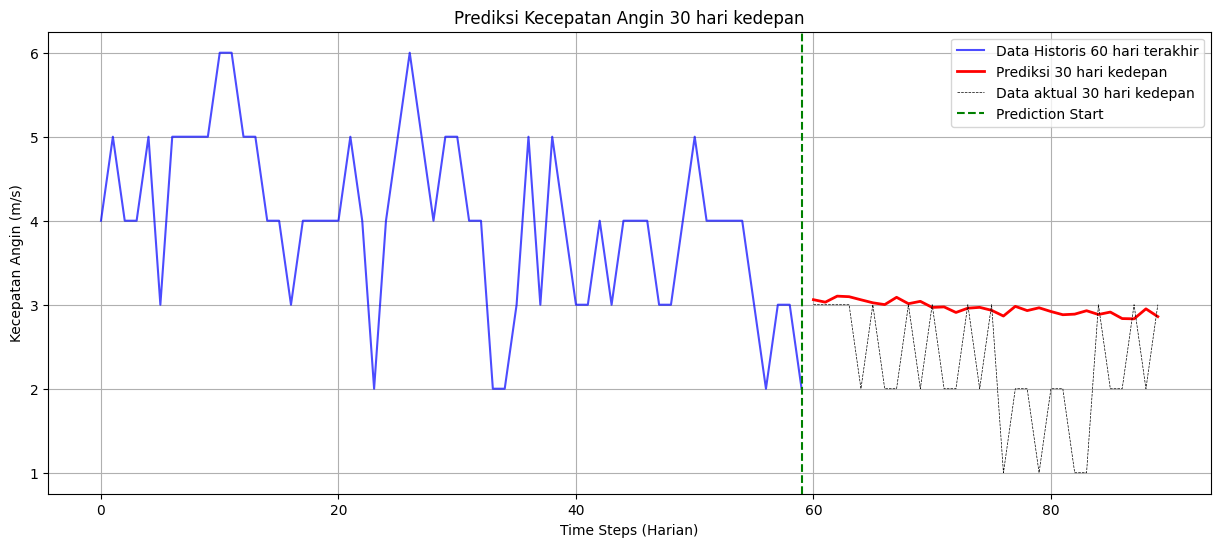

In [160]:
# Plot prediksi masa depan
plt.figure(figsize=(15, 6))

# Plot beberapa data terakhir sebagai konteks
context_data = latest_sequence_raw
context_x = range(len(context_data))
future_x = range(len(context_data), len(context_data) + len(next_30_forecast))
actual_x = range(len(context_data), len(context_data) + len(array_next_30_actual))

plt.plot(context_x, context_data, label='Data Historis 60 hari terakhir', color='blue', alpha=0.7)
plt.plot(future_x, next_30_forecast, label='Prediksi 30 hari kedepan', color='red', linewidth=2)
plt.plot(actual_x, array_next_30_actual, label='Data aktual 30 hari kedepan', color='black', linestyle='--', linewidth=0.5)
plt.axvline(x=len(context_data)-1, color='green', linestyle='--', label='Prediction Start')

plt.title('Prediksi Kecepatan Angin 30 hari kedepan')
plt.xlabel('Time Steps (Harian)')
plt.ylabel('Kecepatan Angin (m/s)')
plt.legend()
plt.grid(True)
plt.show()